# Respiratory Disease (Asthma) — Data Exploration and Cleaning

This notebook explores and cleans the uploaded `asthma_dataset.csv` dataset for the Respiratory Disease module of the Multi-Disease Machine Learning System.

## Objective
Build a clean binary-classification dataset for predicting **Asthma Diagnosis**.

## Important modeling decision
Two columns are intentionally excluded from model training:

- **Patient_ID** — identifier only; it has no clinical predictive meaning.
- **Medication** — excluded because it is strongly linked to the diagnosis in this dataset and would create **target leakage**. In the uploaded data, diagnosed patients receive asthma medication while non-diagnosed patients have missing medication values.

The final model features are therefore:

- Age
- Gender
- Smoking Status
- Peak Flow

Target:

- `asthma_diagnosis`: 0 = No asthma, 1 = Asthma


## 1. Environment Setup and File Locations

This cell imports the required libraries, finds the project root, and defines the paths for the raw asthma dataset, processed dataset, and report figures.

The separation between raw and processed data helps preserve reproducibility and keeps cleaning operations traceable.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Detect project root whether the notebook is opened from the
# project folder or from the notebooks folder.
current_folder = Path.cwd()
project_root = (
    current_folder.parent
    if current_folder.name == "notebooks"
    else current_folder
)

raw_data_path = (
    project_root
    / "data"
    / "raw"
    / "asthma_dataset.csv"
)

processed_data_path = (
    project_root
    / "data"
    / "processed"
    / "respiratory_disease_clean.csv"
)

figures_folder = (
    project_root
    / "reports"
    / "figures"
)

processed_data_path.parent.mkdir(parents=True, exist_ok=True)
figures_folder.mkdir(parents=True, exist_ok=True)

print("Raw dataset path:", raw_data_path)
print("File exists:", raw_data_path.exists())

if not raw_data_path.exists():
    raise FileNotFoundError(
        "Place asthma_dataset.csv inside data/raw before running this notebook."
    )

Raw dataset path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\data\raw\asthma_dataset.csv
File exists: True


## 2. Loading the Raw Asthma Dataset

The raw respiratory/asthma CSV is loaded without modifying the source file.

The dataset dimensions, columns, and an initial preview are inspected so the available variables are understood before any cleaning or feature selection is performed.


In [2]:
# Load the raw dataset
asthma_raw = pd.read_csv(raw_data_path)

print("Dataset loaded successfully.")
print("Dataset shape:", asthma_raw.shape)
print("\nColumns:")
print(asthma_raw.columns.tolist())

print("\nData types:")
print(asthma_raw.dtypes)

display(asthma_raw.head())

Dataset loaded successfully.
Dataset shape: (300, 7)

Columns:
['Patient_ID', 'Age', 'Gender', 'Smoking_Status', 'Asthma_Diagnosis', 'Medication', 'Peak_Flow']

Data types:
Patient_ID          int64
Age                 int64
Gender                str
Smoking_Status        str
Asthma_Diagnosis      str
Medication            str
Peak_Flow           int64
dtype: object


,Patient_ID,Age,Gender,Smoking_Status,Asthma_Diagnosis,Medication,Peak_Flow
0,1,26,Female,Non-Smoker,Yes,Inhaler,175
1,2,52,Female,Ex-Smoker,No,NaN,156
2,3,56,Female,Ex-Smoker,Yes,Inhaler,236
3,4,55,Male,Current Smoker,Yes,Controller Medication,378
4,5,43,Female,Current Smoker,No,NaN,159


## 3. Initial Data-Quality Assessment

The notebook summarizes missing values, unique values, duplicate rows, and target distribution.

This step establishes the condition of the dataset before preprocessing and identifies issues that could influence model training or evaluation.


In [3]:
# Initial data-quality summary
quality_summary = pd.DataFrame(
    {
        "Data Type": asthma_raw.dtypes.astype(str),
        "Missing Values": asthma_raw.isnull().sum(),
        "Missing Percentage": (
            asthma_raw.isnull().mean().mul(100).round(2)
        ),
        "Unique Values": asthma_raw.nunique(dropna=True),
    }
)

display(
    quality_summary.sort_values(
        "Missing Values",
        ascending=False,
    )
)

print("Duplicated rows:", asthma_raw.duplicated().sum())

print("\nTarget distribution:")
print(
    asthma_raw["Asthma_Diagnosis"]
    .value_counts(dropna=False)
)

print("\nAge statistics:")
display(asthma_raw["Age"].describe().to_frame().T)

print("\nPeak Flow statistics:")
display(asthma_raw["Peak_Flow"].describe().to_frame().T)

,Data Type,Missing Values,Missing Percentage,Unique Values
Medication,str,143,47.67,2
Age,int64,0,0.00,48
Patient_ID,int64,0,0.00,300
Gender,str,0,0.00,2
Smoking_Status,str,0,0.00,3
Asthma_Diagnosis,str,0,0.00,2
Peak_Flow,int64,0,0.00,178


Duplicated rows: 0

Target distribution:
Asthma_Diagnosis
Yes    157
No     143
Name: count, dtype: int64

Age statistics:


,count,mean,std,min,25%,50%,75%,max
Age,300.0,39.666667,14.059675,18.0,27.0,39.0,51.0,65.0



Peak Flow statistics:


,count,mean,std,min,25%,50%,75%,max
Peak_Flow,300.0,278.943333,72.861027,150.0,216.5,279.0,340.25,400.0


## 4. Inspecting Categorical Variables

The observed values of categorical columns are printed explicitly.

This makes inconsistent spelling, capitalization, whitespace, or unexpected category labels easier to detect before the variables are standardized and encoded for machine learning.


In [4]:
# Inspect categorical values
categorical_columns = [
    "Gender",
    "Smoking_Status",
    "Asthma_Diagnosis",
    "Medication",
]

for column in categorical_columns:
    print(f"\n{column}")
    print(asthma_raw[column].value_counts(dropna=False))


Gender
Gender
Female    159
Male      141
Name: count, dtype: int64

Smoking_Status
Smoking_Status
Non-Smoker        109
Current Smoker    100
Ex-Smoker          91
Name: count, dtype: int64

Asthma_Diagnosis
Asthma_Diagnosis
Yes    157
No     143
Name: count, dtype: int64

Medication
Medication
NaN                      143
Controller Medication     84
Inhaler                   73
Name: count, dtype: int64


## Target-leakage check

A feature should not contain information that is only available **after** the target condition is known.

Here, `Medication` is suspicious because medication prescription can depend on whether asthma has already been diagnosed. We therefore inspect its relationship with the target before deciding whether to use it.


## 5. Target-Leakage Investigation

The relationship between `Medication` and the asthma diagnosis is examined directly.

If a feature strongly reflects information that would normally become known only after diagnosis, using it as a predictor can create **target leakage**. A model may then appear highly accurate because it is indirectly receiving the answer rather than learning generalizable pre-diagnosis patterns.

This check is therefore a key methodological safeguard in the respiratory module.


In [5]:
# Check whether Medication leaks the asthma diagnosis
medication_target_table = pd.crosstab(
    asthma_raw["Asthma_Diagnosis"],
    asthma_raw["Medication"].fillna("Missing"),
    margins=True,
)

display(medication_target_table)

print(
    "\nIf medication status perfectly or almost perfectly separates the target, "
    "it must not be used as an input feature."
)

Medication,Controller Medication,Inhaler,Missing,All
Asthma_Diagnosis,,,,
No,0,0,143,143
Yes,84,73,0,157
All,84,73,143,300



If medication status perfectly or almost perfectly separates the target, it must not be used as an input feature.


## Cleaning strategy

1. Normalize column names.
2. Strip whitespace from categorical values.
3. Convert the target from Yes/No to 1/0.
4. Remove `Patient_ID`.
5. Remove `Medication` to prevent target leakage.
6. Validate age, peak-flow, gender, smoking-status, and target values.
7. Save the clean dataset for model training.


## 6. Cleaning and Leakage-Safe Feature Selection

A clean working copy is created and column names and categorical values are standardized.

Two important fields are excluded from the predictive feature set:

- `Patient_ID`, because it is only an identifier.
- `Medication`, because it is considered leakage-prone for this prediction task.

The remaining features are intended to represent information that could plausibly be available before the target diagnosis is known.


In [6]:
# Create a clean working copy
asthma_clean = asthma_raw.copy()

# Standardize column names
asthma_clean.columns = [
    column.strip().lower()
    for column in asthma_clean.columns
]

# Strip and normalize object/text values
for column in asthma_clean.select_dtypes(include="object").columns:
    asthma_clean[column] = (
        asthma_clean[column]
        .astype("string")
        .str.strip()
    )

# Rename columns to consistent project naming
asthma_clean = asthma_clean.rename(
    columns={
        "patient_id": "patient_id",
        "age": "age",
        "gender": "gender",
        "smoking_status": "smoking_status",
        "asthma_diagnosis": "asthma_diagnosis",
        "medication": "medication",
        "peak_flow": "peak_flow",
    }
)

# Normalize categorical text
asthma_clean["gender"] = (
    asthma_clean["gender"]
    .str.lower()
)

asthma_clean["smoking_status"] = (
    asthma_clean["smoking_status"]
    .str.lower()
    .str.replace("-", "_", regex=False)
    .str.replace(" ", "_", regex=False)
)

asthma_clean["asthma_diagnosis"] = (
    asthma_clean["asthma_diagnosis"]
    .str.lower()
)

# Convert numeric features
asthma_clean["age"] = pd.to_numeric(
    asthma_clean["age"],
    errors="coerce",
)

asthma_clean["peak_flow"] = pd.to_numeric(
    asthma_clean["peak_flow"],
    errors="coerce",
)

# Convert target to binary
target_mapping = {
    "no": 0,
    "yes": 1,
}

asthma_clean["asthma_diagnosis"] = (
    asthma_clean["asthma_diagnosis"]
    .map(target_mapping)
)

# Remove columns that must not be used for training
asthma_clean = asthma_clean.drop(
    columns=[
        "patient_id",
        "medication",
    ]
)

display(asthma_clean.head())
print("Cleaned dataset shape:", asthma_clean.shape)

C:\Users\20247\AppData\Local\Temp\ipykernel_17088\1454971451.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in asthma_clean.select_dtypes(include="object").columns:


,age,gender,smoking_status,asthma_diagnosis,peak_flow
0,26,female,non_smoker,1,175
1,52,female,ex_smoker,0,156
2,56,female,ex_smoker,1,236
3,55,male,current_smoker,1,378
4,43,female,current_smoker,0,159


Cleaned dataset shape: (300, 5)


## 7. Validation of Expected Categories and Ranges

The cleaned categorical values and selected numerical ranges are checked against the expected dataset structure.

This confirms that the standardization process did not create unexpected categories and helps detect malformed records before the data are saved for modeling.


In [7]:
# Validate expected values
expected_gender = {"male", "female"}

expected_smoking_status = {
    "non_smoker",
    "current_smoker",
    "ex_smoker",
}

observed_gender = set(
    asthma_clean["gender"].dropna().unique()
)

observed_smoking_status = set(
    asthma_clean["smoking_status"].dropna().unique()
)

unexpected_gender = observed_gender - expected_gender
unexpected_smoking = (
    observed_smoking_status - expected_smoking_status
)

print("Unexpected gender values:", unexpected_gender)
print("Unexpected smoking-status values:", unexpected_smoking)

if asthma_clean["asthma_diagnosis"].isnull().any():
    raise ValueError(
        "Unexpected or missing values were found in the asthma target."
    )

# Basic range checks
invalid_age_rows = asthma_clean[
    (asthma_clean["age"] < 0)
    | (asthma_clean["age"] > 120)
]

invalid_peak_flow_rows = asthma_clean[
    asthma_clean["peak_flow"] <= 0
]

print("Invalid age rows:", len(invalid_age_rows))
print("Invalid peak-flow rows:", len(invalid_peak_flow_rows))

if unexpected_gender:
    raise ValueError(
        f"Unexpected gender values: {unexpected_gender}"
    )

if unexpected_smoking:
    raise ValueError(
        f"Unexpected smoking-status values: {unexpected_smoking}"
    )

Unexpected gender values: set()
Unexpected smoking-status values: set()
Invalid age rows: 0
Invalid peak-flow rows: 0


## 8. Final Data-Quality Summary

The cleaned dataset is reviewed again after preprocessing decisions have been applied.

This second audit confirms the final missing-value pattern, feature types, unique values, and target structure that will be passed to the model-training notebook.


In [8]:
# Final quality summary
final_summary = pd.DataFrame(
    {
        "Data Type": asthma_clean.dtypes.astype(str),
        "Missing Values": asthma_clean.isnull().sum(),
        "Missing Percentage": (
            asthma_clean.isnull().mean().mul(100).round(2)
        ),
        "Unique Values": asthma_clean.nunique(dropna=True),
    }
)

display(final_summary)

print("Final dataset shape:", asthma_clean.shape)
print("Duplicated rows:", asthma_clean.duplicated().sum())

print("\nFinal target distribution:")
target_counts = (
    asthma_clean["asthma_diagnosis"]
    .value_counts()
    .sort_index()
)
print(target_counts)

print("\nTarget percentages:")
print(
    target_counts
    .div(target_counts.sum())
    .mul(100)
    .round(2)
)

,Data Type,Missing Values,Missing Percentage,Unique Values
age,int64,0,0.0,48
gender,string,0,0.0,2
smoking_status,string,0,0.0,3
asthma_diagnosis,int64,0,0.0,2
peak_flow,int64,0,0.0,178


Final dataset shape: (300, 5)
Duplicated rows: 0

Final target distribution:
asthma_diagnosis
0    143
1    157
Name: count, dtype: int64

Target percentages:
asthma_diagnosis
0    47.67
1    52.33
Name: count, dtype: float64


## 9. Target and Peak-Flow Exploration

The target-class distribution and peak-flow behavior are visualized.

These plots help assess whether the classes are balanced and whether peak flow provides visible separation between asthma and non-asthma observations. Substantial overlap suggests that the available leakage-free predictors may have limited discriminative power.


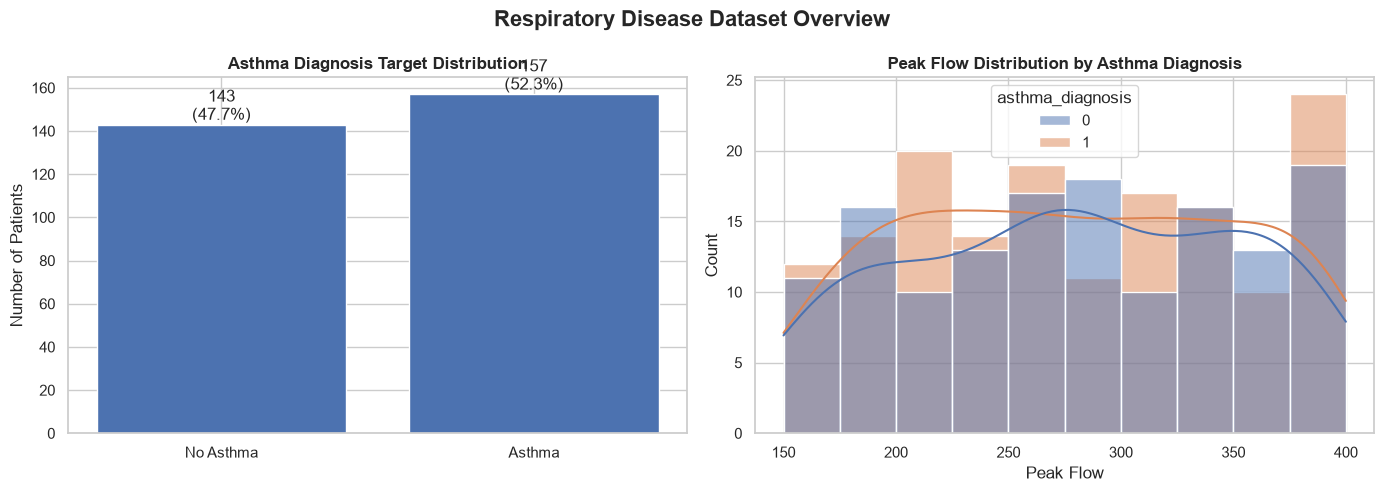

Saved: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\reports\figures\respiratory_dataset_overview.png


In [9]:
# Dataset overview visualizations
figure, axes = plt.subplots(1, 2, figsize=(14, 5))

target_counts = (
    asthma_clean["asthma_diagnosis"]
    .value_counts()
    .sort_index()
)

target_labels = ["No Asthma", "Asthma"]

axes[0].bar(
    target_labels,
    target_counts.values,
)

for index, count in enumerate(target_counts.values):
    percentage = count / target_counts.sum() * 100
    axes[0].text(
        index,
        count,
        f"{count}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
    )

axes[0].set_title(
    "Asthma Diagnosis Target Distribution",
    fontweight="bold",
)
axes[0].set_ylabel("Number of Patients")

sns.histplot(
    data=asthma_clean,
    x="peak_flow",
    hue="asthma_diagnosis",
    kde=True,
    ax=axes[1],
)

axes[1].set_title(
    "Peak Flow Distribution by Asthma Diagnosis",
    fontweight="bold",
)
axes[1].set_xlabel("Peak Flow")

figure.suptitle(
    "Respiratory Disease Dataset Overview",
    fontsize=16,
    fontweight="bold",
)

plt.tight_layout()

overview_path = (
    figures_folder
    / "respiratory_dataset_overview.png"
)

plt.savefig(
    overview_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", overview_path)

## 10. Smoking Status and Diagnosis

A cross-tabulation and visualization compare asthma-diagnosis proportions across smoking-status categories.

The purpose is exploratory: it shows whether smoking status changes the observed class proportions, but it does not by itself establish causation or guarantee strong predictive value.


asthma_diagnosis,0,1
smoking_status,,
current_smoker,44.00,56.00
ex_smoker,57.14,42.86
non_smoker,43.12,56.88


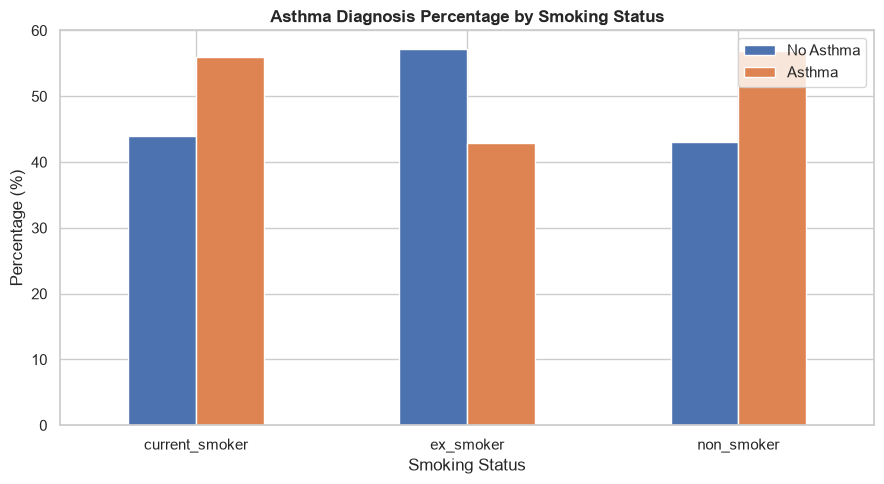

Saved: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\reports\figures\respiratory_smoking_target.png


In [10]:
# Smoking-status distribution by target
smoking_target = pd.crosstab(
    asthma_clean["smoking_status"],
    asthma_clean["asthma_diagnosis"],
    normalize="index",
).mul(100)

display(smoking_target.round(2))

smoking_target.plot(
    kind="bar",
    figsize=(9, 5),
)

plt.title(
    "Asthma Diagnosis Percentage by Smoking Status",
    fontweight="bold",
)
plt.xlabel("Smoking Status")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(["No Asthma", "Asthma"])
plt.tight_layout()

smoking_figure_path = (
    figures_folder
    / "respiratory_smoking_target.png"
)

plt.savefig(
    smoking_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", smoking_figure_path)

## 11. Numerical Features by Target Class

Numerical variables are summarized separately for the two target classes.

This comparison helps identify whether variables such as age or peak flow show meaningful shifts between asthma and non-asthma groups before any model is trained.


In [11]:
# Compare numerical features by target
group_summary = (
    asthma_clean
    .groupby("asthma_diagnosis")[["age", "peak_flow"]]
    .agg(["mean", "std", "median", "min", "max"])
)

display(group_summary.round(2))

# Point-biserial style Pearson correlation with the binary target
numerical_correlations = (
    asthma_clean[
        ["age", "peak_flow", "asthma_diagnosis"]
    ]
    .corr(numeric_only=True)["asthma_diagnosis"]
    .drop("asthma_diagnosis")
    .sort_values()
)

display(
    numerical_correlations
    .to_frame("Correlation with asthma target")
    .round(4)
)

age                       peak_flow                     \
                   mean    std median min max      mean    std median  min   
asthma_diagnosis                                                             
0                 38.58  13.71   36.0  18  65    279.24  72.68  281.0  152   
1                 40.66  14.34   43.0  18  65    278.67  73.26  274.0  150   

                       
                  max  
asthma_diagnosis       
0                 400  
1                 398

,Correlation with asthma target
peak_flow,-0.0040
age,0.0739


## 12. Saving the Leakage-Free Processed Dataset

Only the selected leakage-safe predictors and the binary target are written to the processed CSV.

The processed dataset becomes the input to the respiratory model-training notebook. Preserving this exact feature set ensures that the later model is evaluated without the identifier and medication leakage fields.


In [12]:
# Save the processed dataset
final_columns = [
    "age",
    "gender",
    "smoking_status",
    "peak_flow",
    "asthma_diagnosis",
]

asthma_clean = asthma_clean[final_columns]

asthma_clean.to_csv(
    processed_data_path,
    index=False,
)

# Reload to verify the saved output
saved_data = pd.read_csv(processed_data_path)

print("Processed dataset saved successfully.")
print("Saved path:", processed_data_path)
print("Saved shape:", saved_data.shape)
print("Columns:", saved_data.columns.tolist())
print(
    "Target values:",
    sorted(saved_data["asthma_diagnosis"].unique()),
)

display(saved_data.head())

Processed dataset saved successfully.
Saved path: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\data\processed\respiratory_disease_clean.csv
Saved shape: (300, 5)
Columns: ['age', 'gender', 'smoking_status', 'peak_flow', 'asthma_diagnosis']
Target values: [np.int64(0), np.int64(1)]


,age,gender,smoking_status,peak_flow,asthma_diagnosis
0,26,female,non_smoker,175,1
1,52,female,ex_smoker,156,0
2,56,female,ex_smoker,236,1
3,55,male,current_smoker,378,1
4,43,female,current_smoker,159,0


## Exploration conclusions

- The uploaded dataset contains **300 patient records** and **7 original columns**.
- The target is **binary**: Asthma = Yes/No.
- `Medication` contains missing values for non-asthma patients and medication values for diagnosed asthma patients, making it a strong **target-leakage feature**. It is therefore excluded from the model.
- `Patient_ID` is also excluded because it is only an identifier.
- The final model uses **4 predictors**:
  - age
  - gender
  - smoking_status
  - peak_flow
- The processed target is:
  - `0` = No asthma
  - `1` = Asthma

### Important limitation
This is a small dataset with only a few predictors. It is suitable for an educational machine-learning project, but model results must not be interpreted as clinical diagnosis or medical probability.
